In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import src.crack_segmentation.multifractal as MFA
import pandas as pd
import csv
import shap
import os
import seaborn as sns
import xgboost as xgb
import statsmodels.api as sm
import pickle

from PIL import Image
from matplotlib import colors
from scipy.io import loadmat
from tqdm import tqdm
from skimage.morphology import thin, skeletonize

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error, r2_score, explained_variance_score

from scipy.interpolate import Rbf, interpn
from scipy.stats import pearsonr

from src.crack_graph.crack_to_graph import crack_to_graph, feature_extraction
from src.crack_segmentation.helper_func import willmott_index_of_agreement
from src.fractal_analysis.Multifractal import multifractal_analysis, calculate_singularity_spectrum, analyze_multifractality

c:\Users\ilham\Documents\Sipil\S2\THESIS\Coding\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ilham\Documents\Sipil\S2\THESIS\Coding\lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


LOAD STEP: 0.25


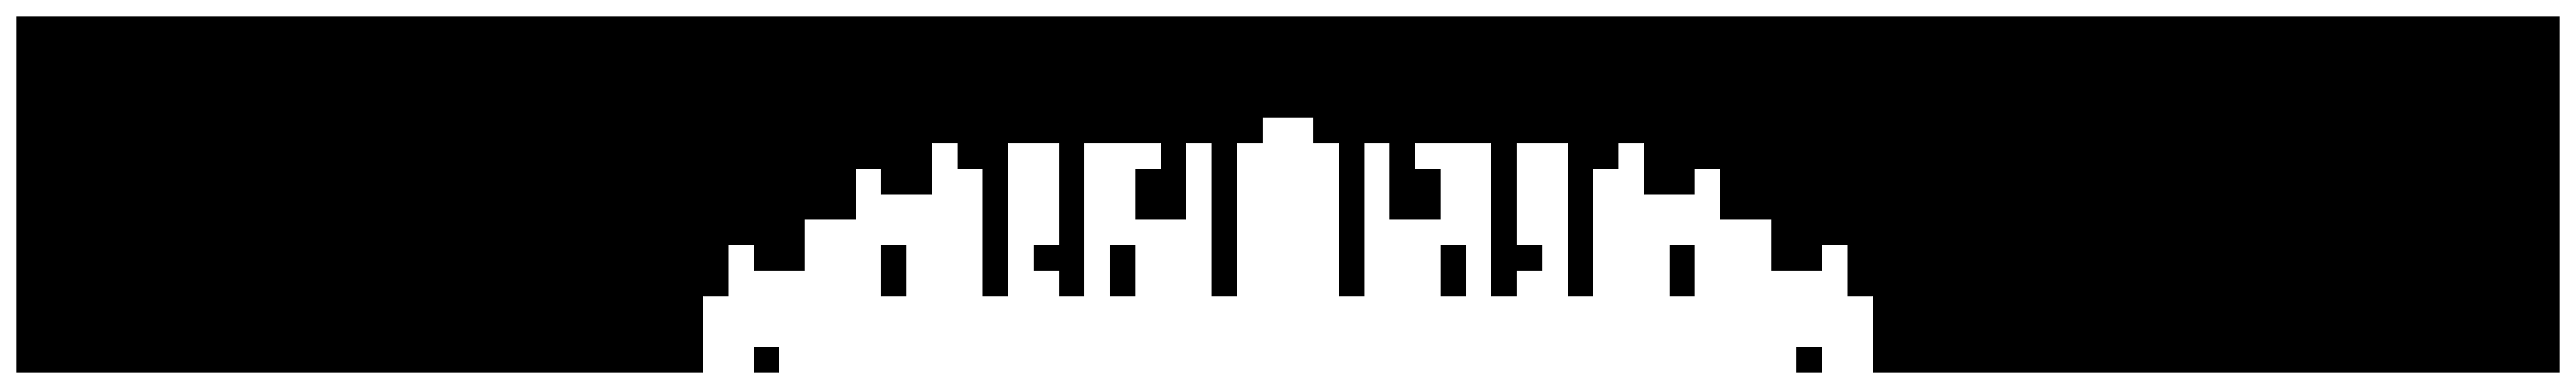

LOAD STEP: 0.38


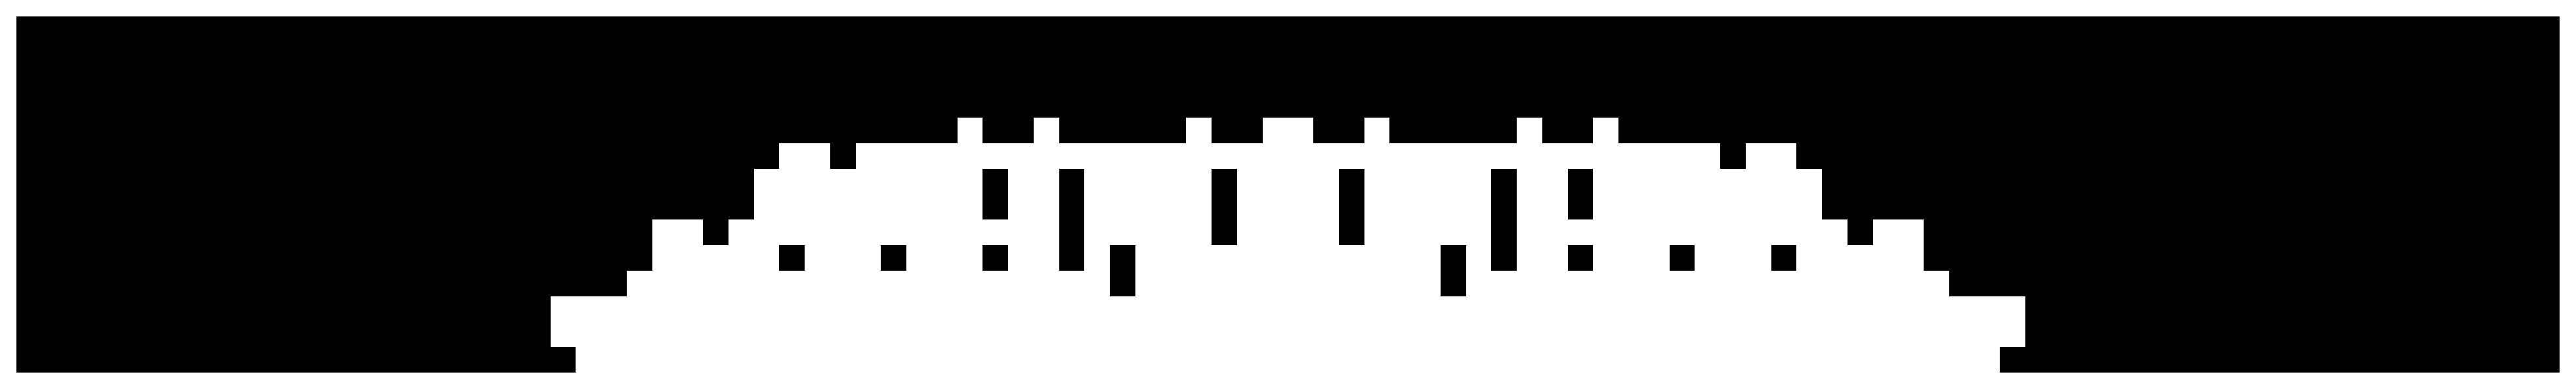

LOAD STEP: 0.5


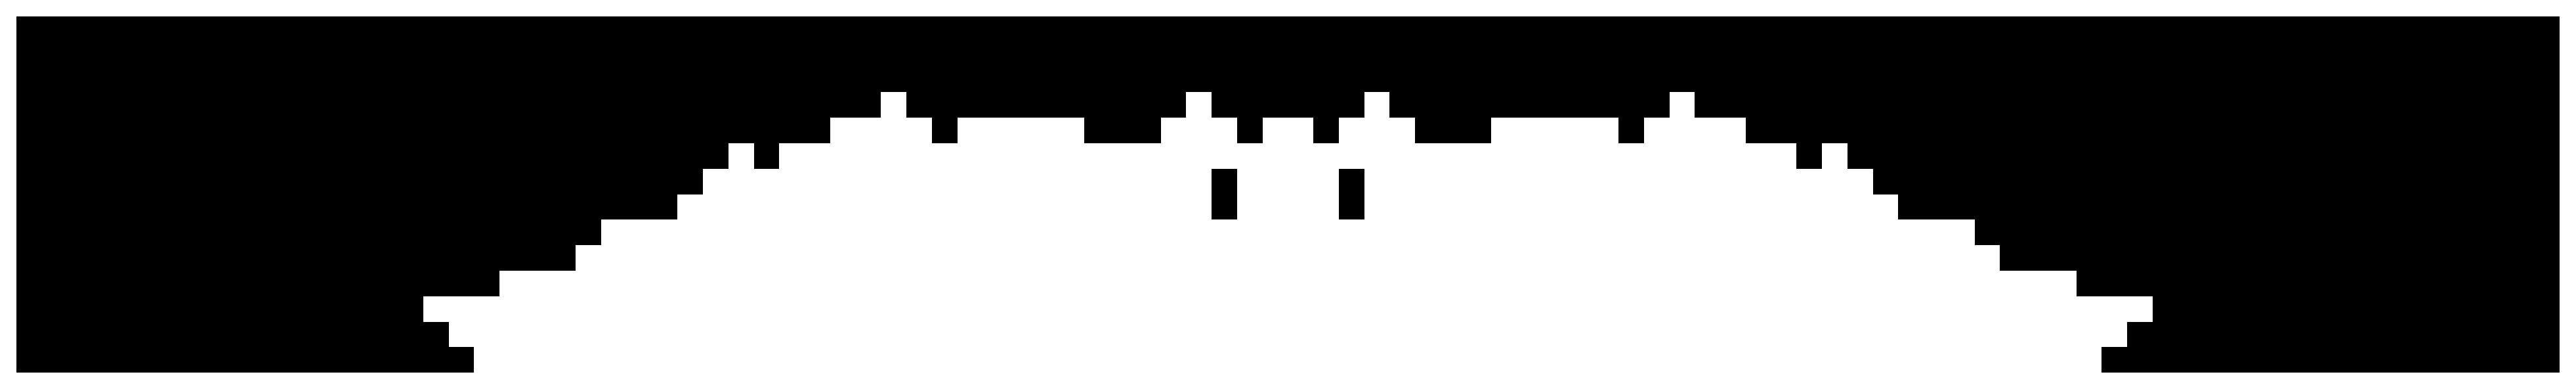

LOAD STEP: 0.63


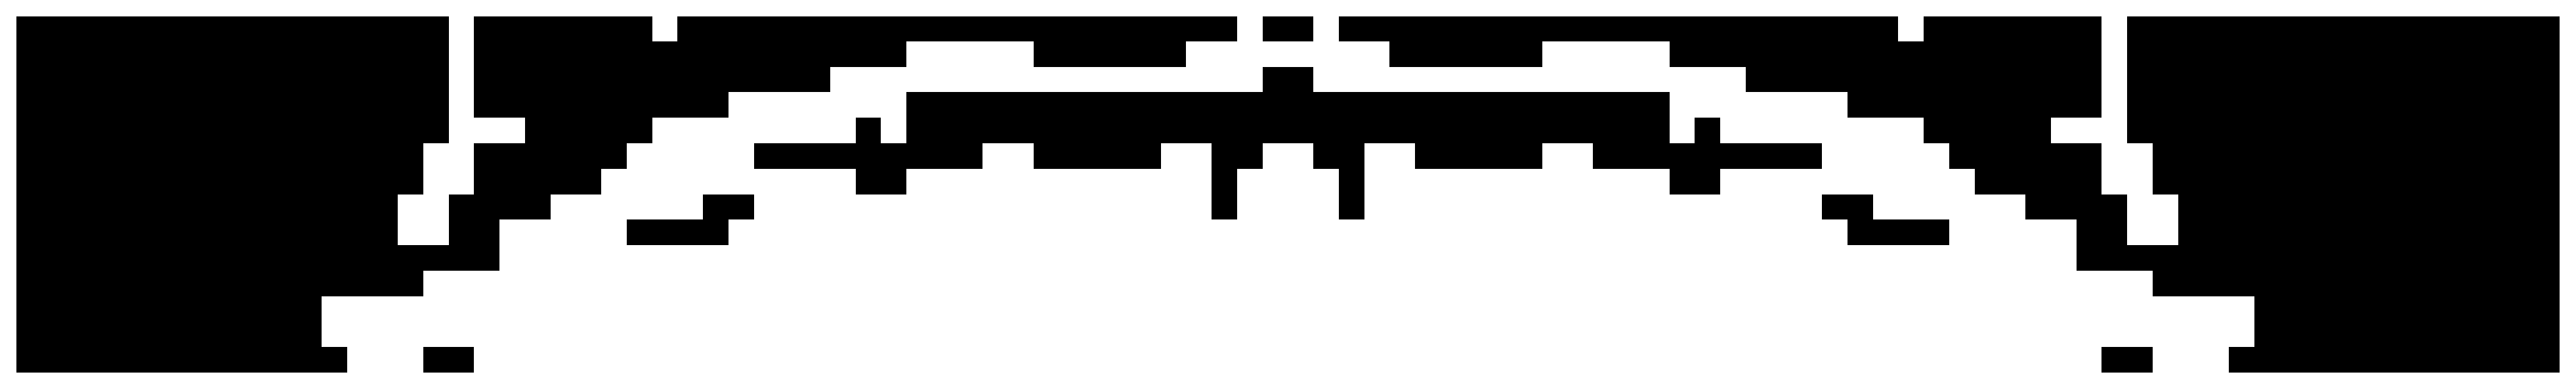

LOAD STEP: 0.76


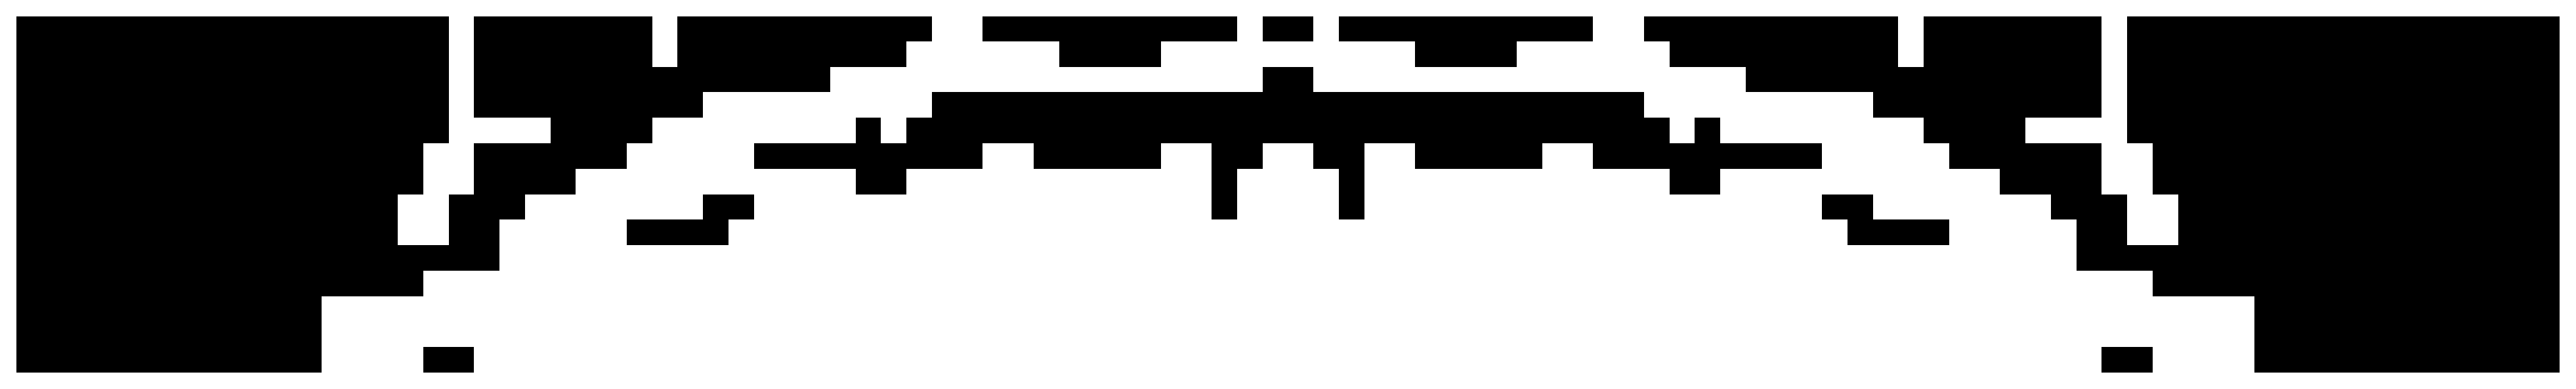

LOAD STEP: 0.88


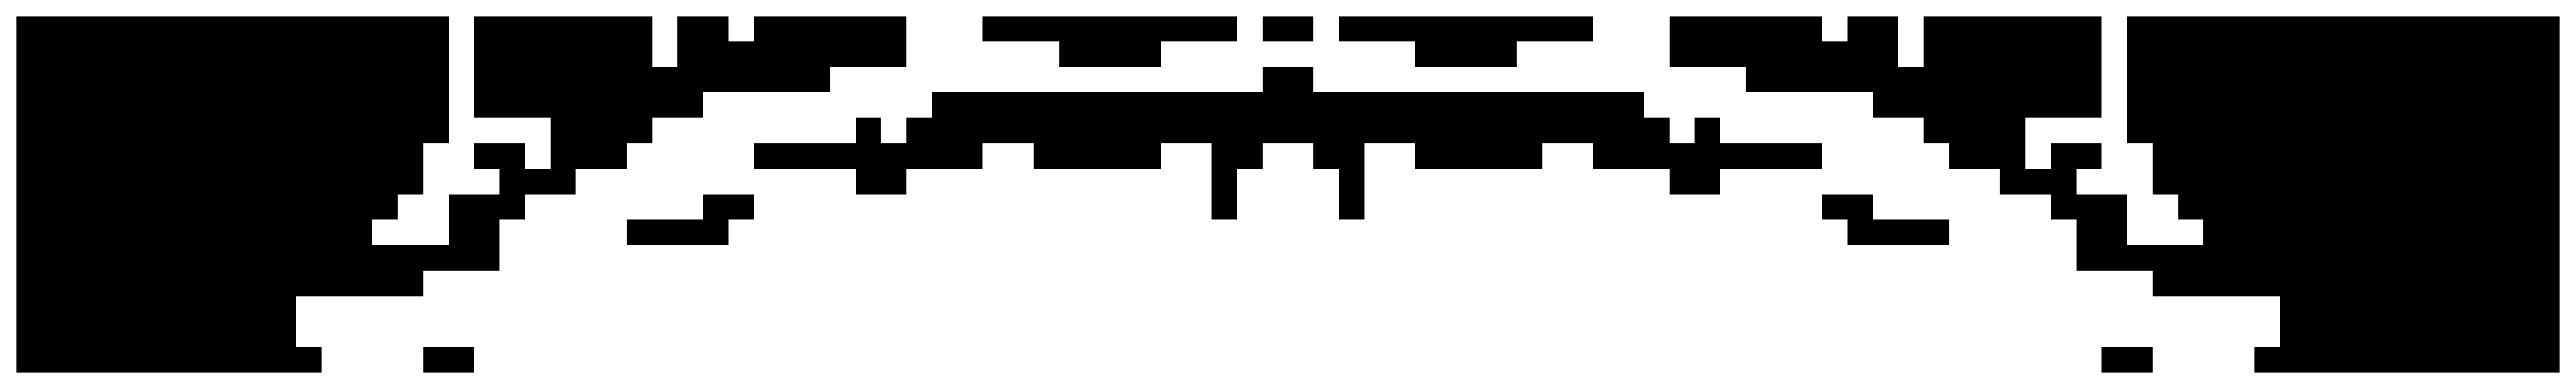

LOAD STEP: 1


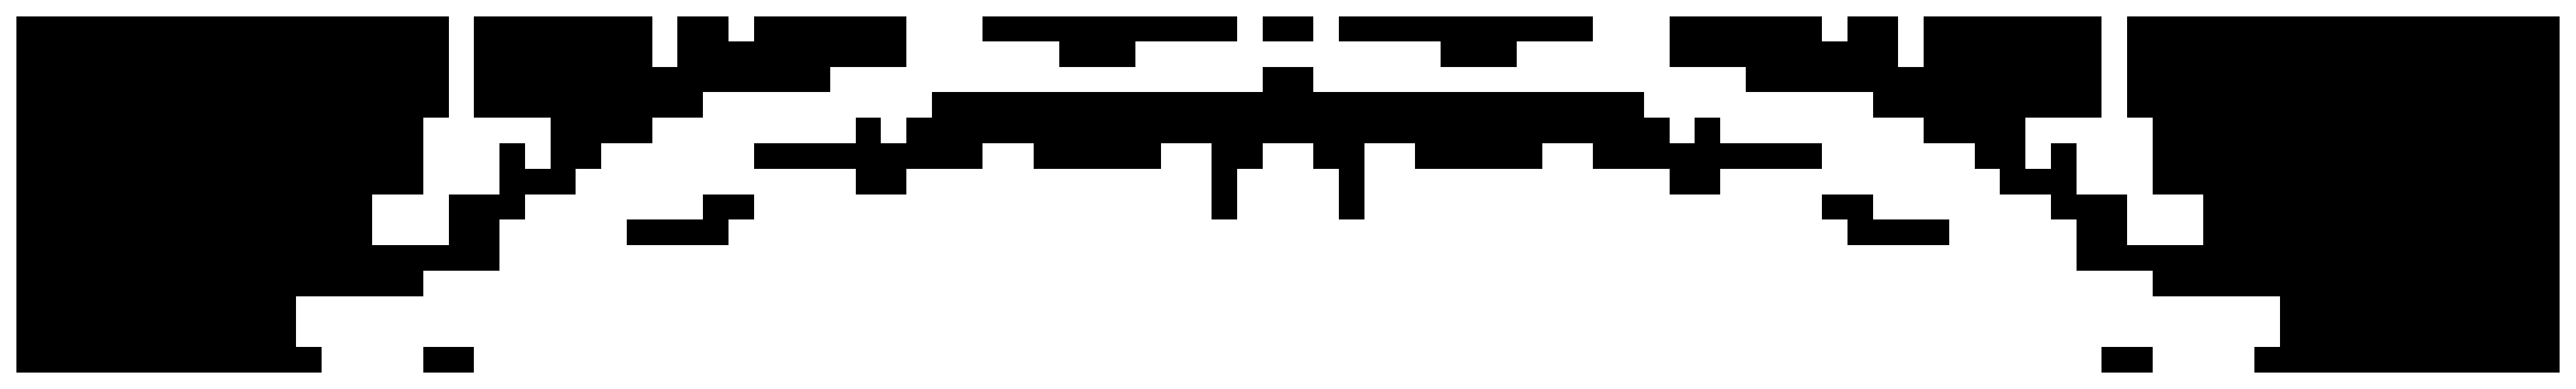

In [8]:
crack_data = pd.read_excel('../Data/midas_output.xlsx', sheet_name='1L')
y = np.array(crack_data['Y'])
y_min = np.min(y)
crack_data = crack_data[crack_data['Y'] == y_min]
# crack_data = crack_data[4:]

x = np.array(crack_data['X'])
z = np.array(crack_data['Z'])

## Complete Data Range

x_unique = np.unique(x)
z_unique = np.unique(z)

for e in x_unique:
    temp_df = pd.DataFrame({'X': [e for _ in range(len(z_unique))], 'Z': z_unique})
    crack_data = pd.merge(crack_data, temp_df, left_on=['X', 'Z'], right_on=['X', 'Z'], how='outer').fillna(0)

# -------------------

# cw = np.array(crack_data['Cwnn (1)'])
load_step = [0.25, 0.38, 0.5, 0.63, 0.76, 0.88, 1]
load_step_file = ['025', '038', '05', '063', '076', '088', '1']

for step, step_name in zip(load_step, load_step_file):
    print(f"LOAD STEP: {step}")
    cw = np.array(crack_data[f'CrackStatus ({step})'])
    cwnn_display = cw.reshape(len(x_unique), len(z_unique))
    cwnn_display = cwnn_display.T
    cwnn_display_h_flip = np.flip(cwnn_display, axis=1)
    cwnn_display_full = np.hstack((cwnn_display, cwnn_display_h_flip))

    plt.figure(figsize=(20, 5), dpi=250)
    # plt.title('Crack Width (Load Step: 1.0)', fontsize=20, weight='bold')
    plt.imshow(cwnn_display_full, cmap='binary_r', origin='lower')
    plt.axis('off')
    plt.savefig(f'./paper_figure/1L-CS-full-{step_name}.png', dpi=250, bbox_inches='tight', pad_inches=0)
    plt.show()

# plt.colorbar(orientation='horizontal', fraction=0.115, pad=0.06)
# plt.savefig('./paper_figure/1L-CS-full-1.png', bbox_inches='tight', pad_inches=0)

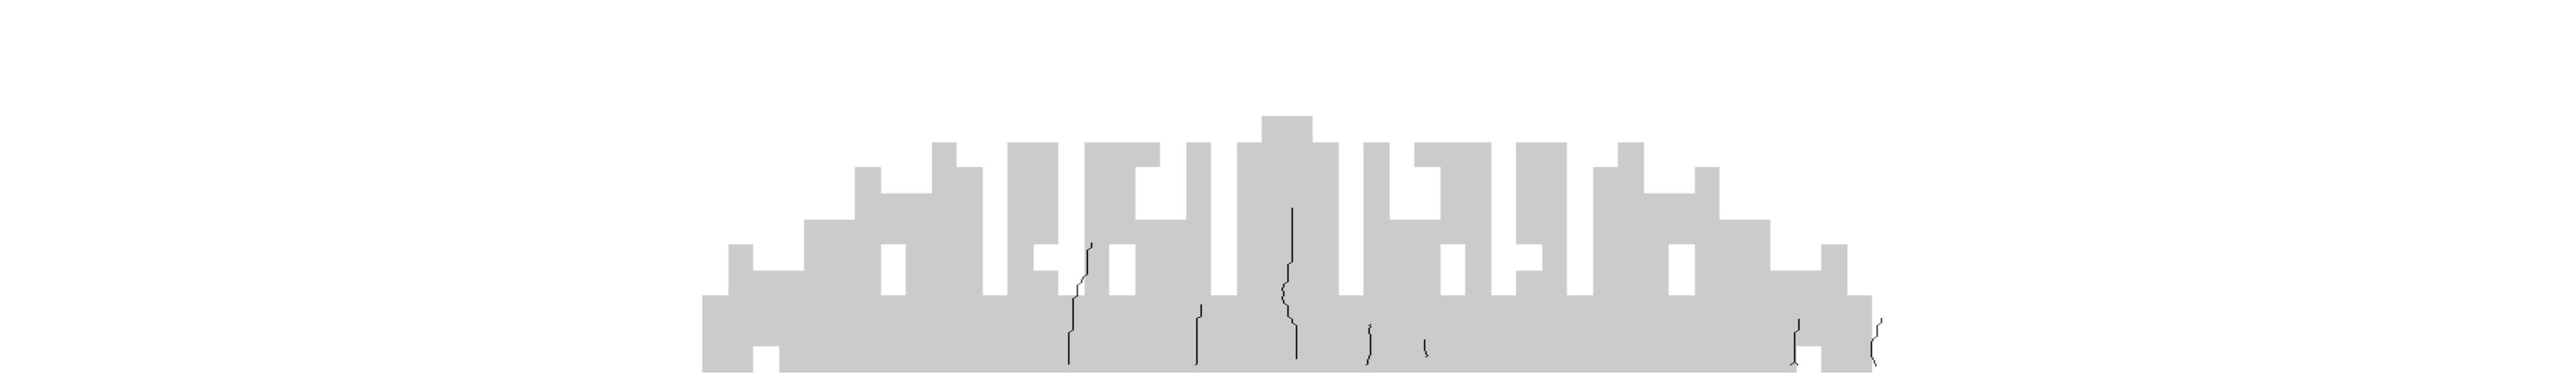

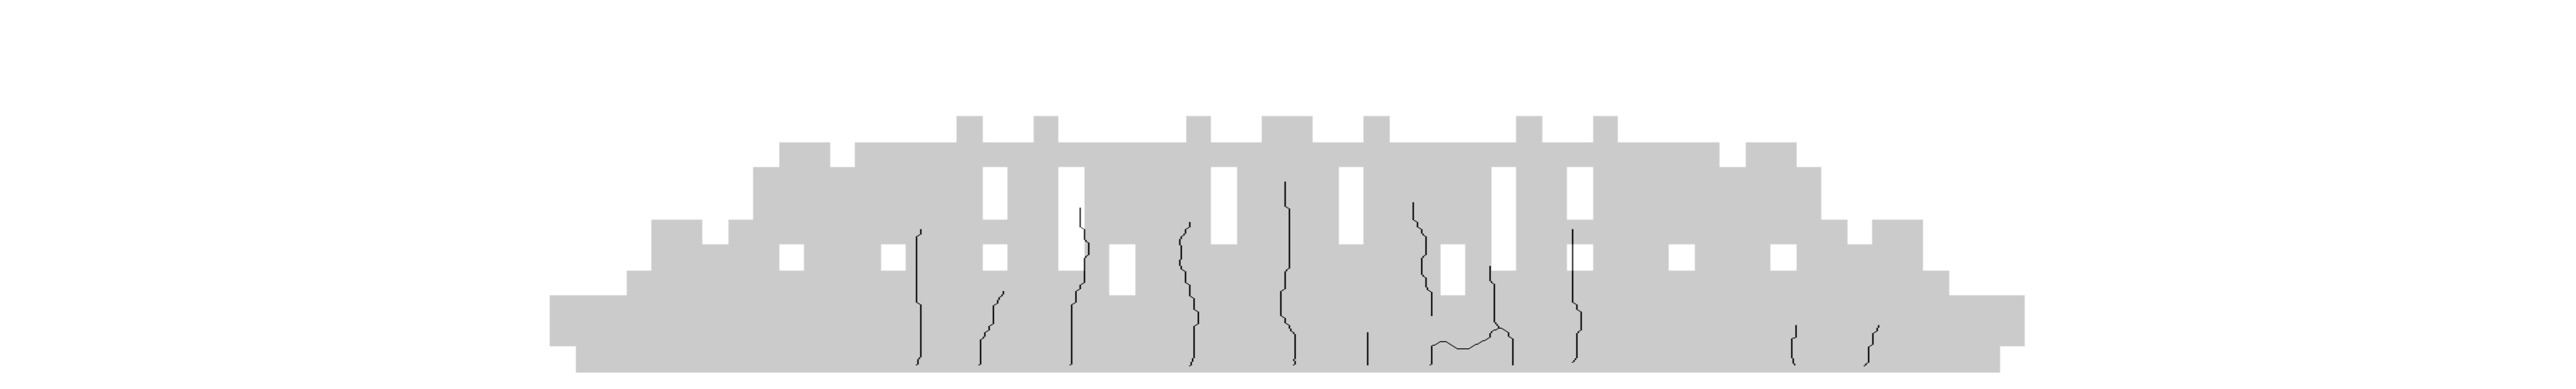

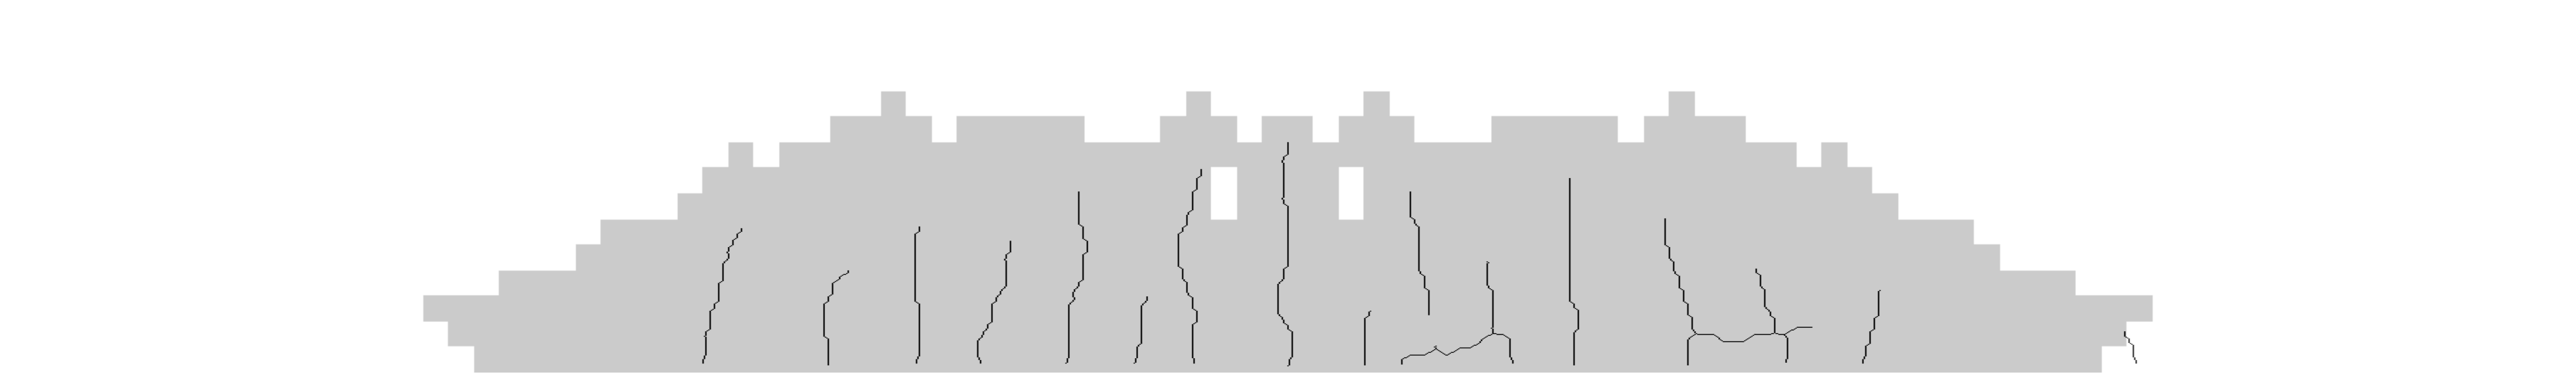

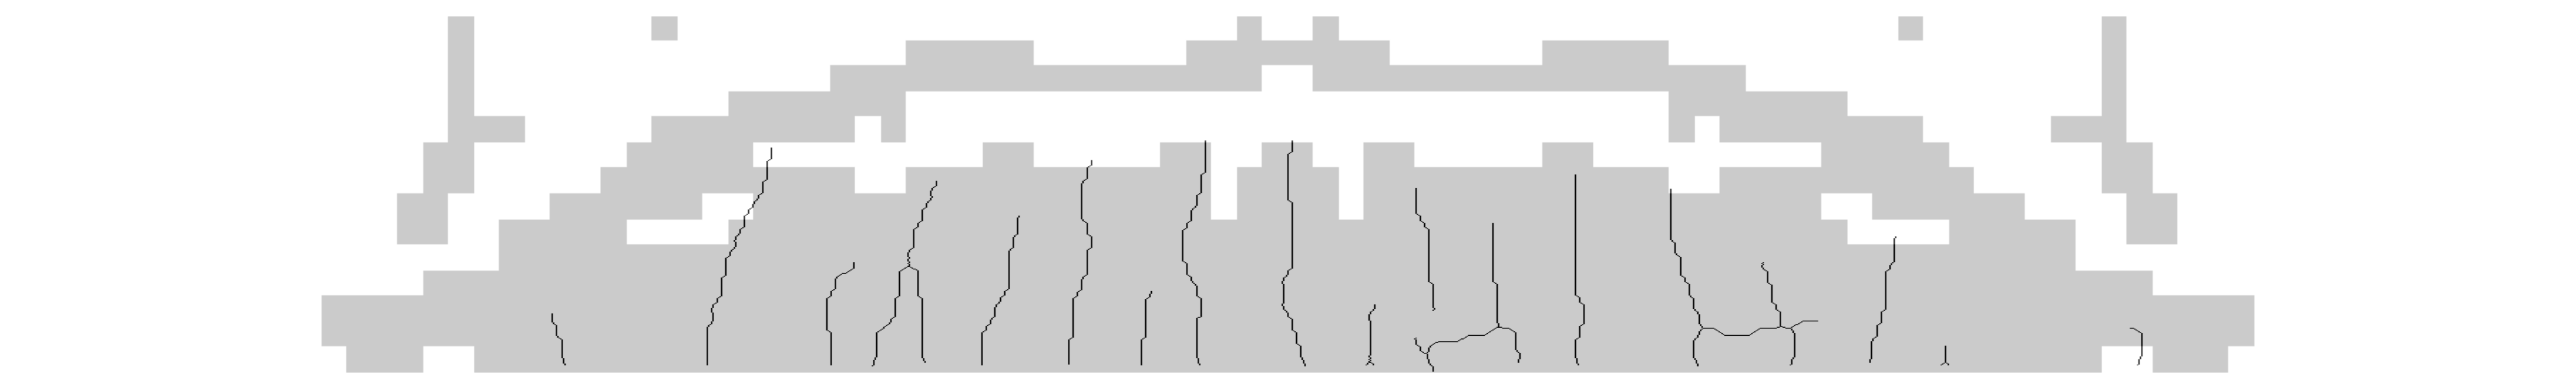

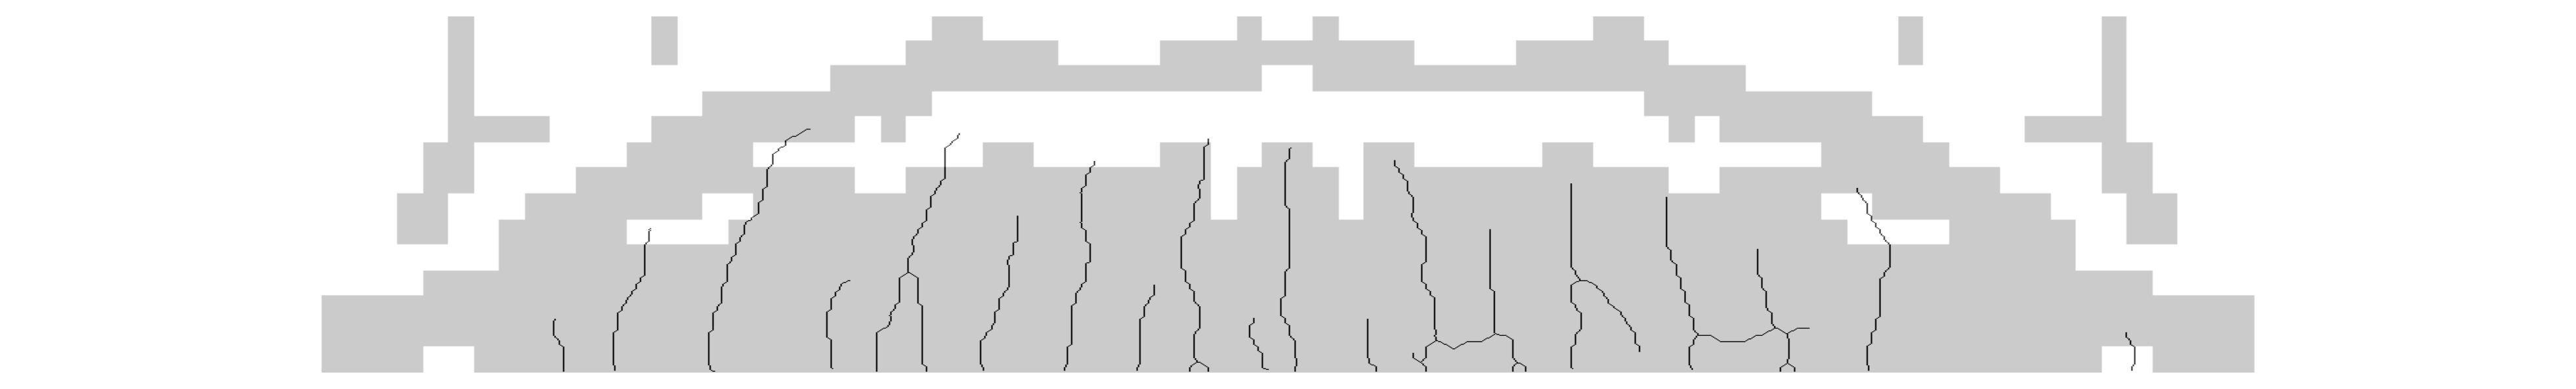

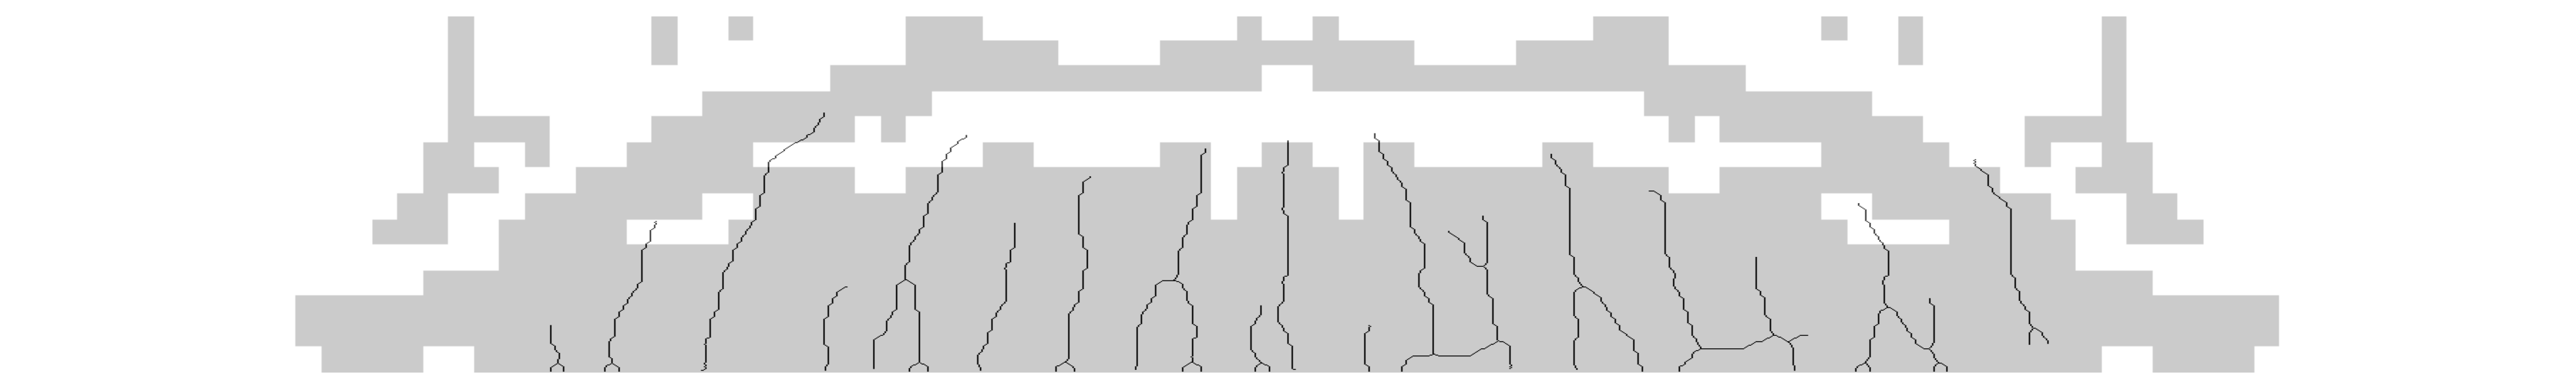

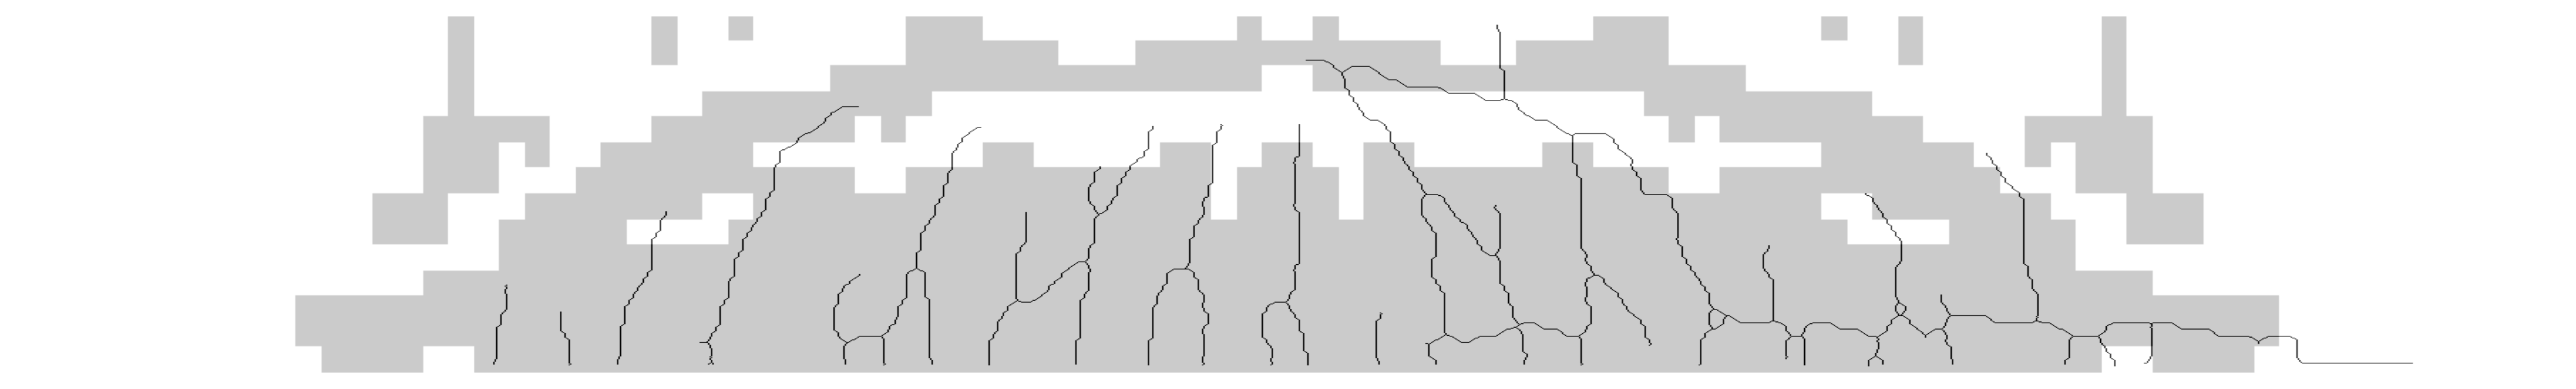

In [38]:
# TRUE_CRACK = '../Image-based load estimation/Data_Codes/All Images/Haunched/5.png'
# FEA_CRACK = './paper_figure/1L-CS-full-06.png'

for image, step in enumerate(load_step_file):
    TRUE_CRACK = f'../Image-based load estimation/Data_Codes/All Images/Haunched/{image+1}.png'
    FEA_CRACK = f'./paper_figure/1L-CS-full-{step}.png'
    fig, ax = plt.subplots(figsize=(20, 5), dpi=250)
    img_1 = cv2.imread(FEA_CRACK)
    img_1 = cv2.cvtColor(img_1, cv2.COLOR_RGB2GRAY)
    img_2 = cv2.imread(TRUE_CRACK)
    img_2 = cv2.cvtColor(img_2, cv2.COLOR_RGB2GRAY)
    fea_img = ax.imshow(img_1, cmap='binary') 
    actual_img = ax.imshow(img_2, cmap='Greys', alpha=0.8, extent=fea_img.get_extent())
    plt.axis('off')
    # plt.savefig('./paper_figure/1L-CS-full-1.png', bbox_inches='tight', pad_inches=0)

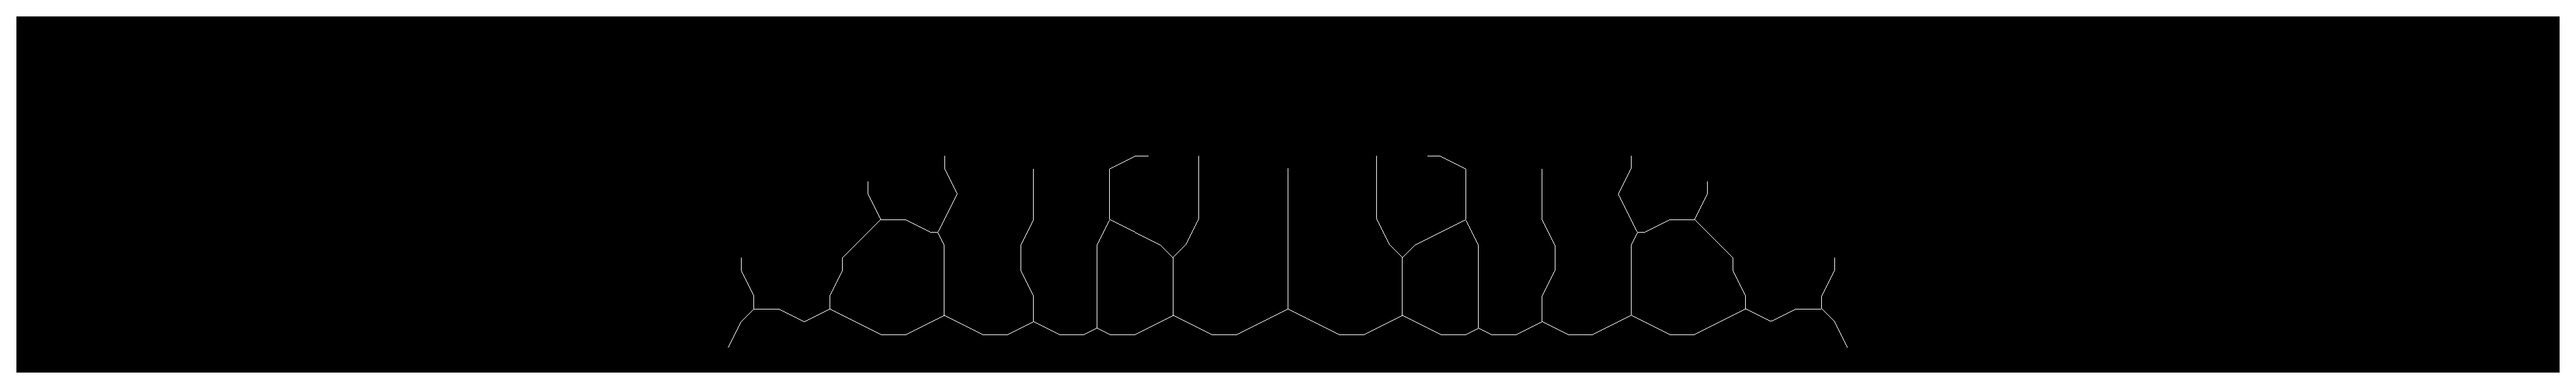

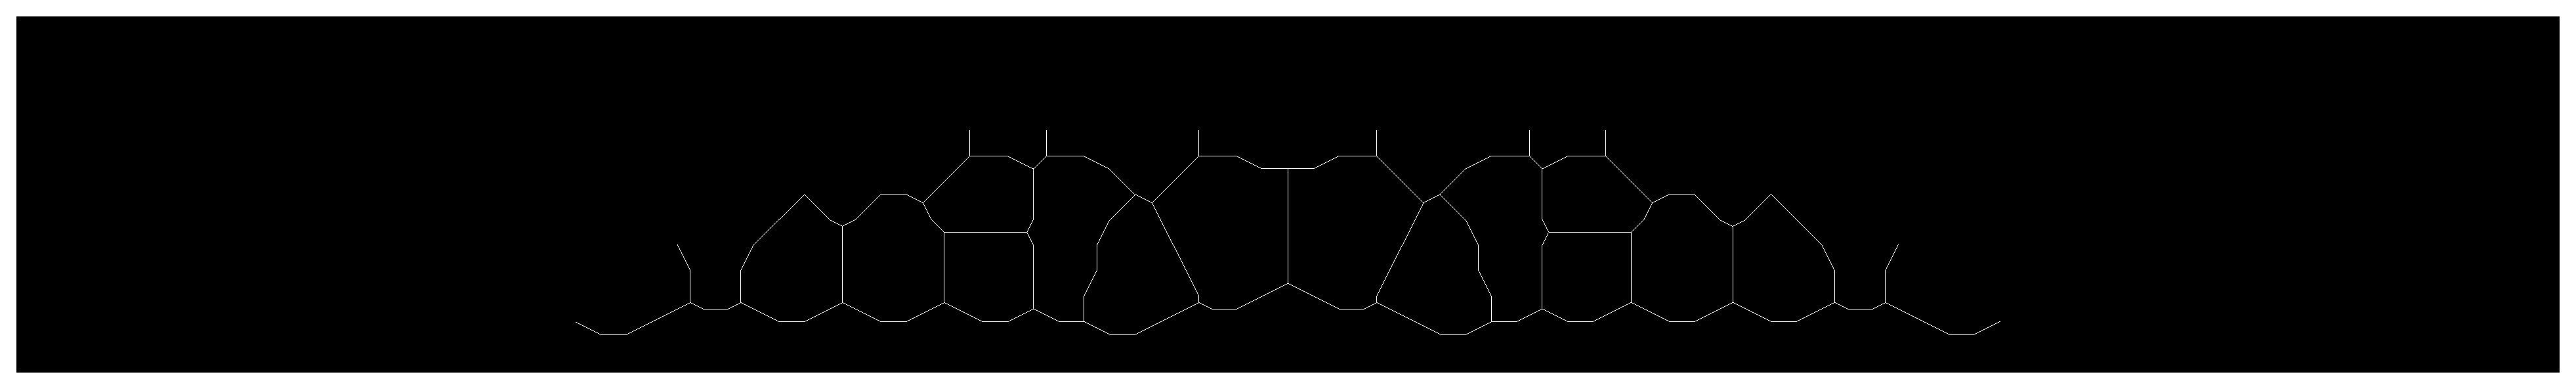

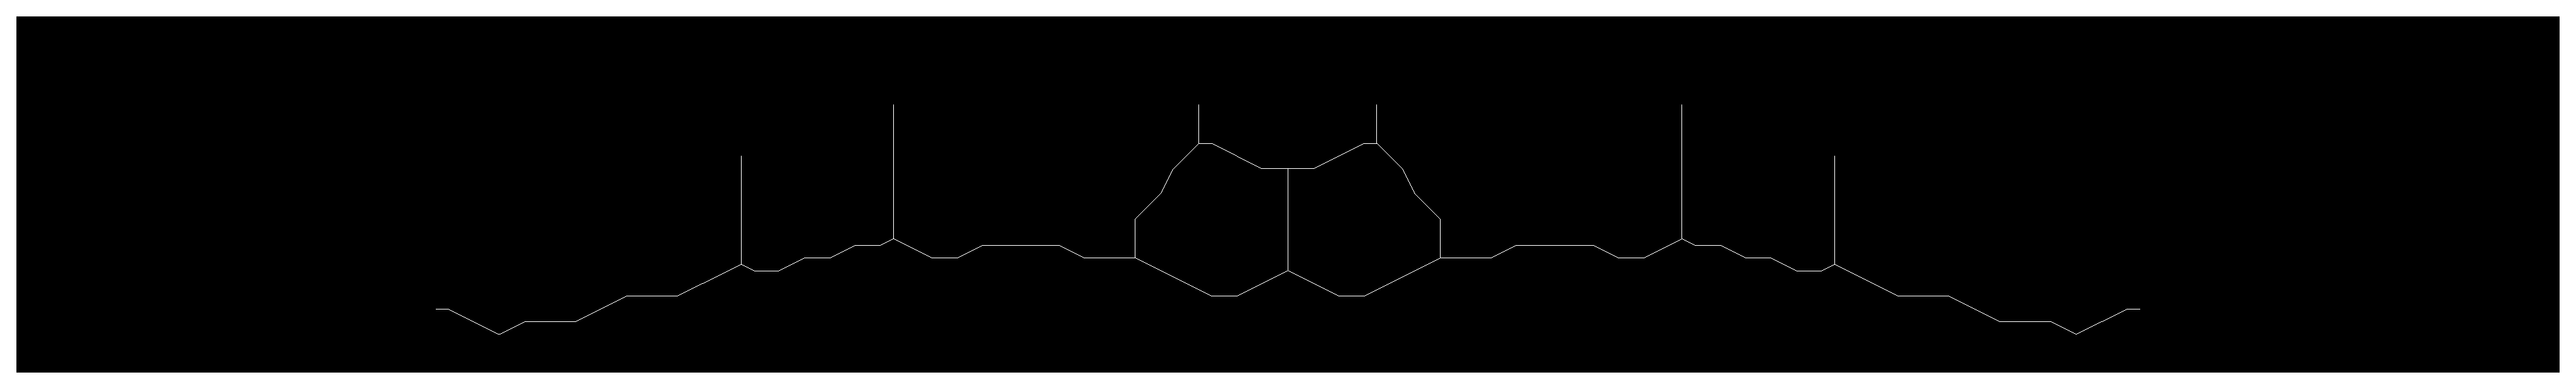

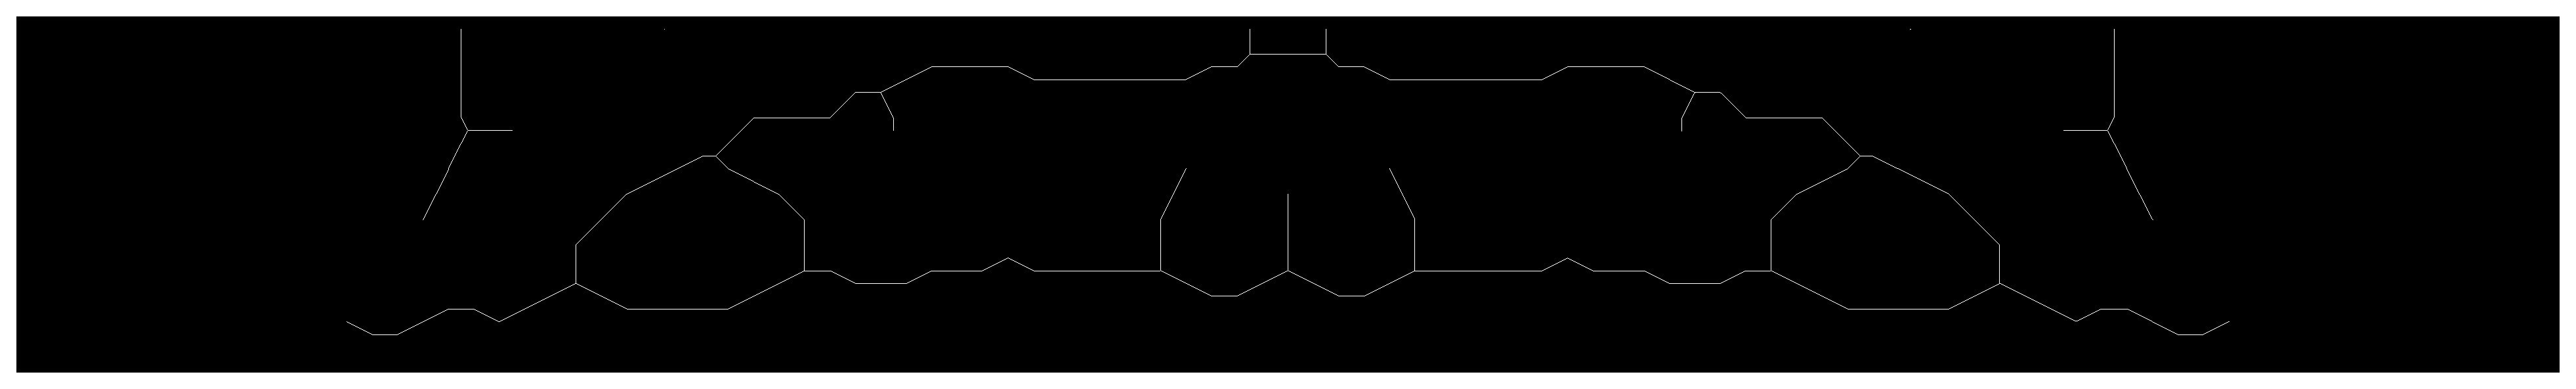

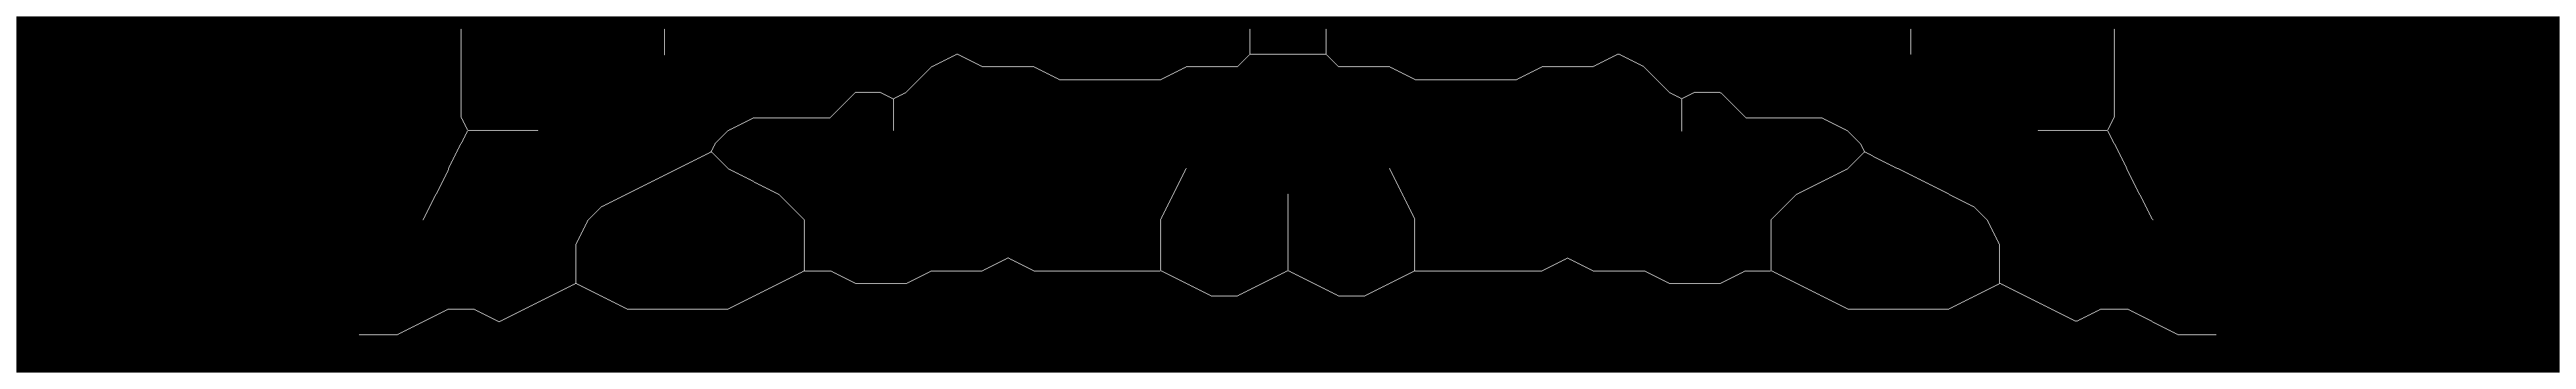

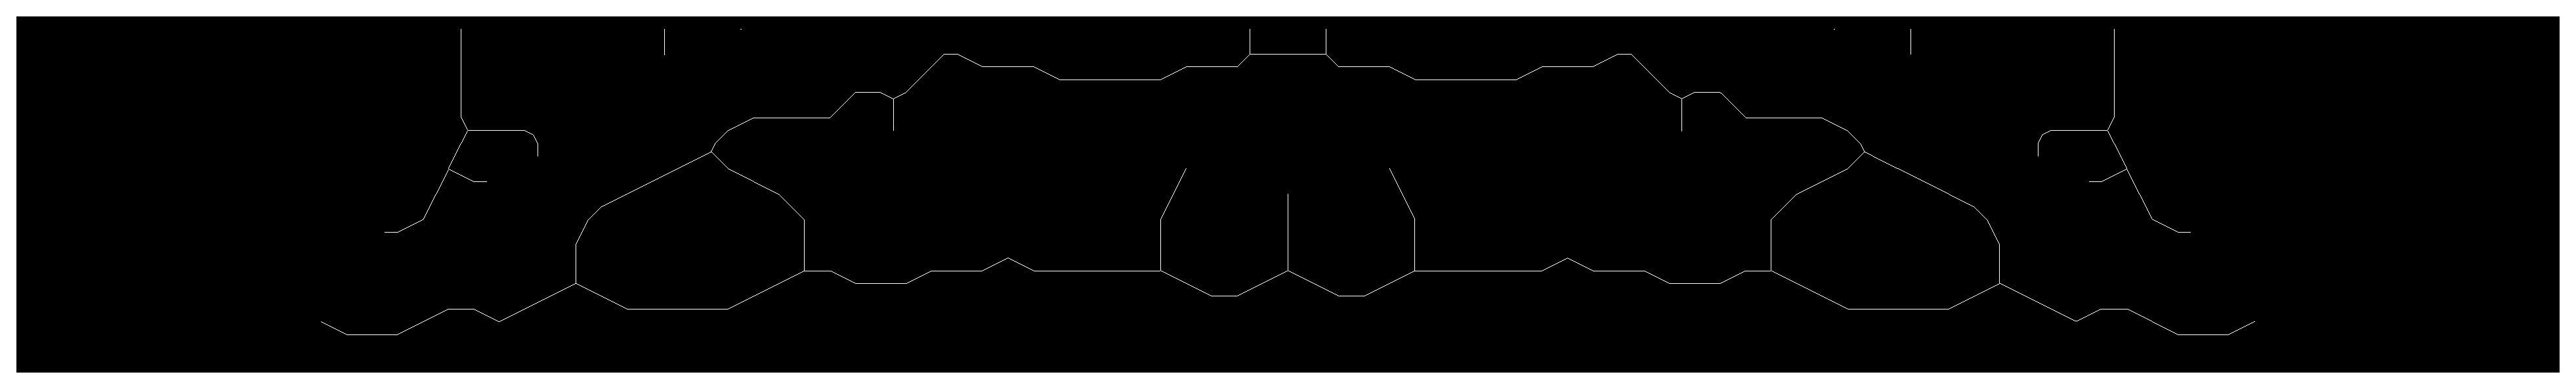

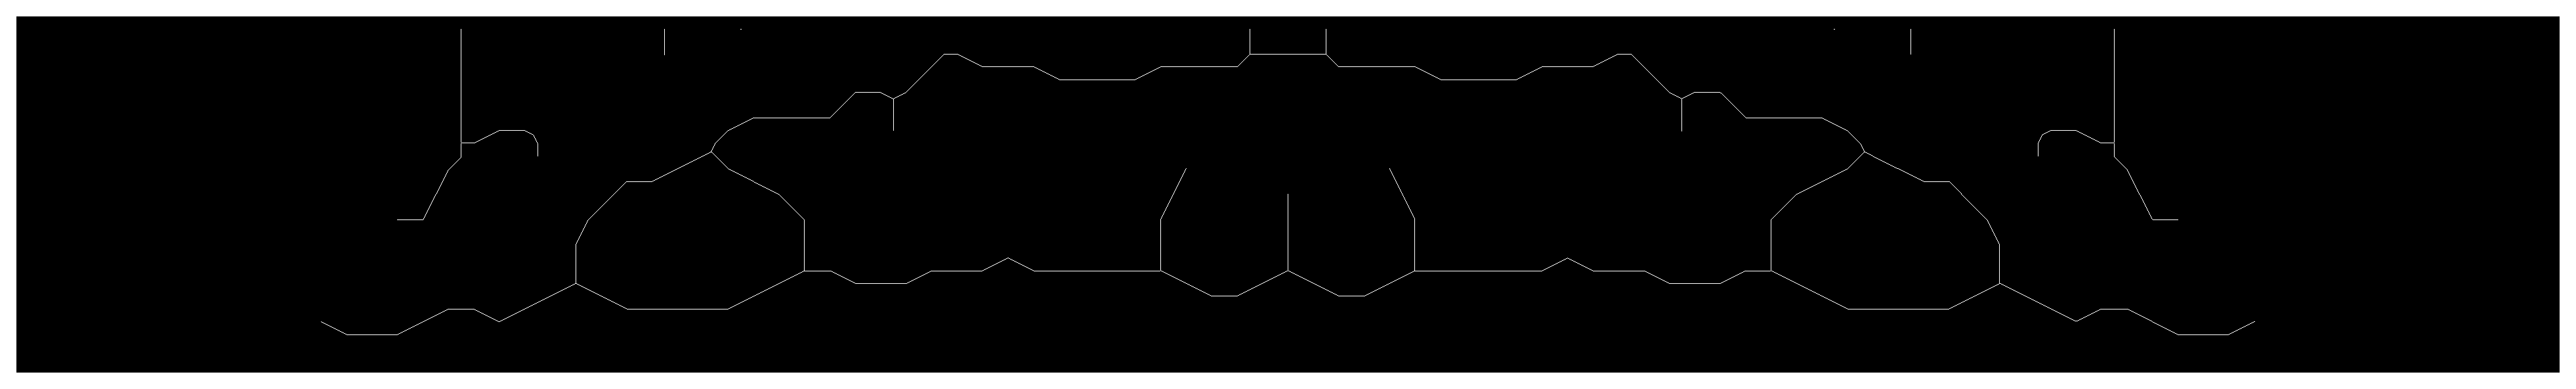

In [14]:
load_step = [0.25, 0.38, 0.5, 0.63, 0.76, 0.88, 1]
load_step_file = ['025', '038', '05', '063', '076', '088', '1']

for step in load_step_file:
    retrive_path = f"./paper_figure/1L-CS-full-{step}.png"
    img = cv2.imread(retrive_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    thin_res = thin(img_gray)
    plt.figure(figsize=(20, 5), dpi=250)
    plt.imshow(thin_res, cmap='binary_r')
    plt.axis(False)
    plt.imsave(f'./paper_figure/1L-thin-{step}-CS-full.png', thin_res, cmap='gray')
    # plt.savefig(f'./paper_figure/1L-thin-{step}-CS-full.png', dpi=1200, bbox_inches='tight', pad_inches=0)
    plt.show()

# thin_res = skeletonize(img_gray)
# plt.figure(figsize=(20, 5), dpi=250)
# plt.imshow(thin_res, cmap='binary_r')
# plt.axis(False)
# plt.show()

# plt.savefig('./paper_figure/1L-skeleton-05-CS-full.png', bbox_inches='tight', pad_inches=0)

STEP: 025
[0.58811384]


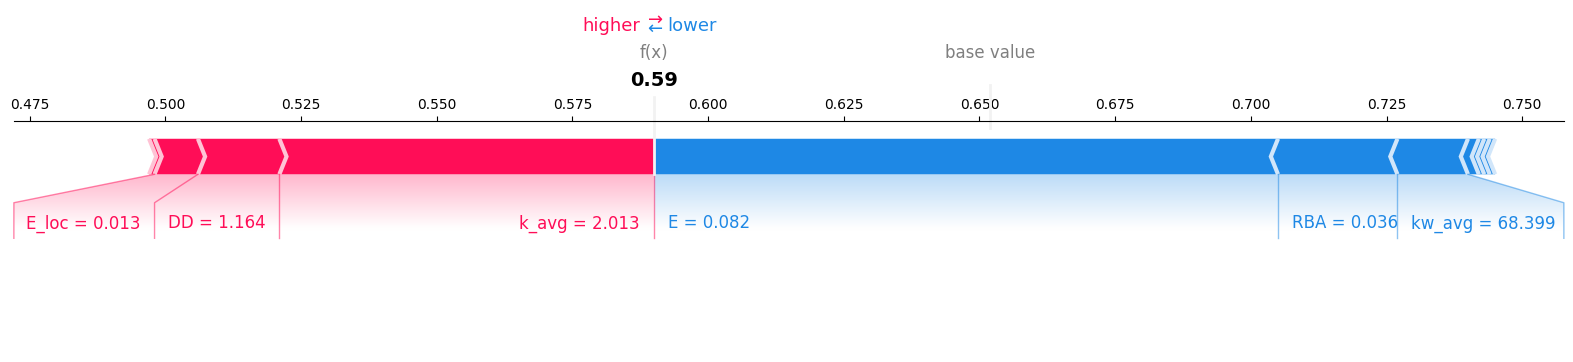

STEP: 038
[0.5544877]


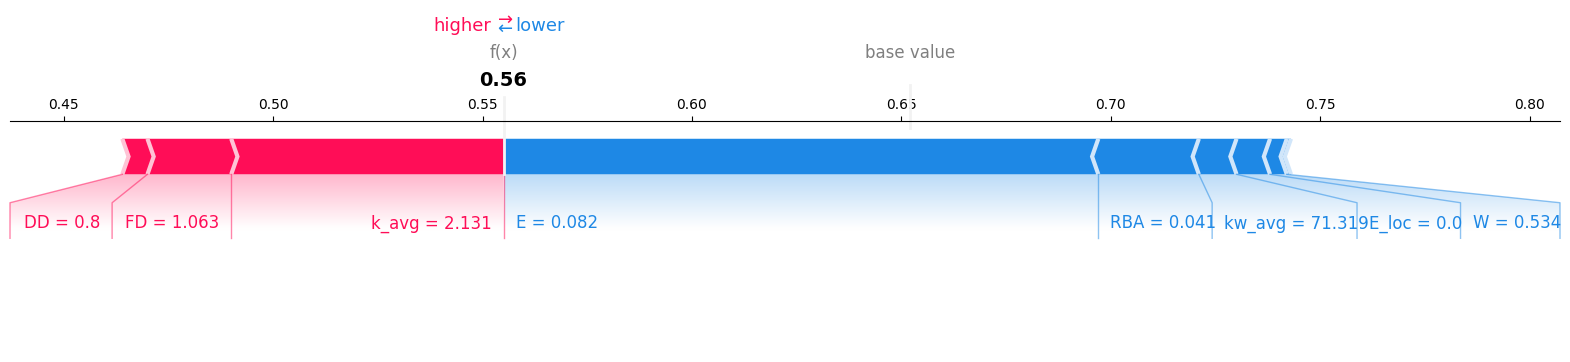

STEP: 05
[0.4855258]


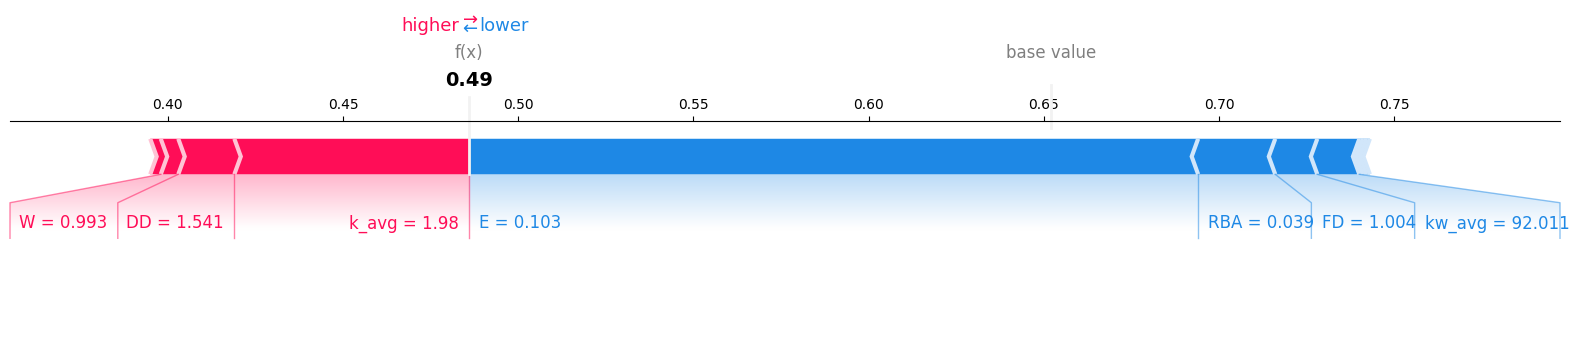

STEP: 063
[0.58927166]


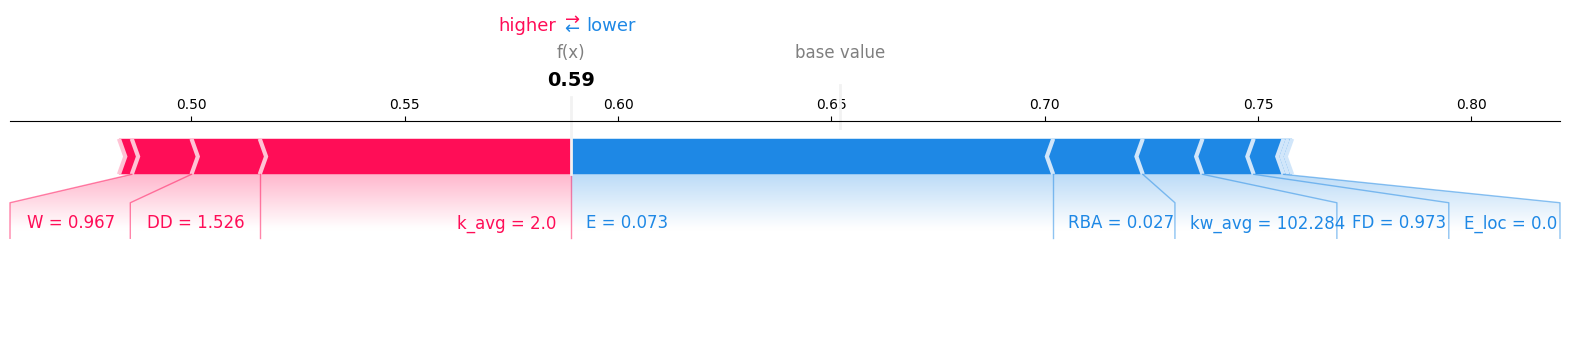

STEP: 076
[0.5546846]


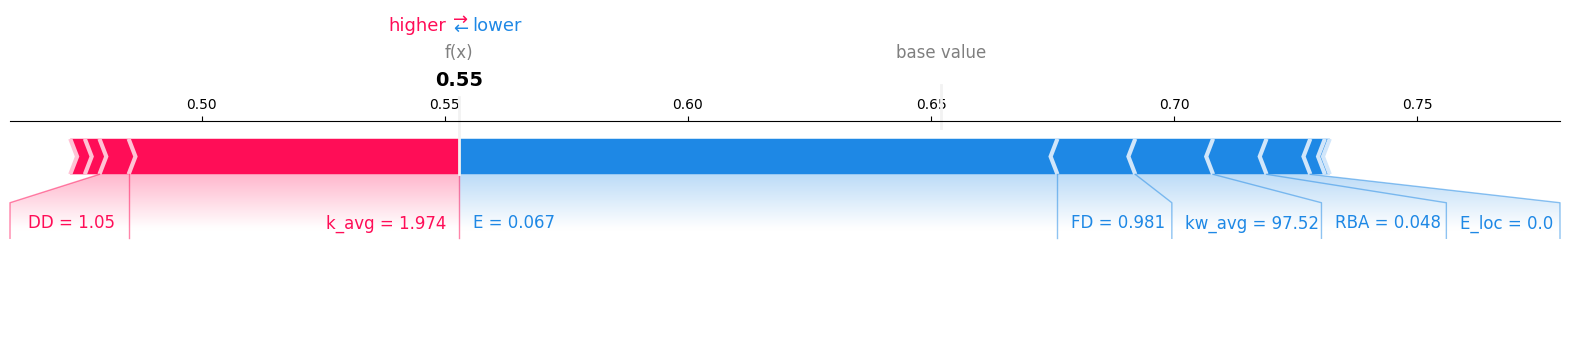

STEP: 088
[0.6522806]


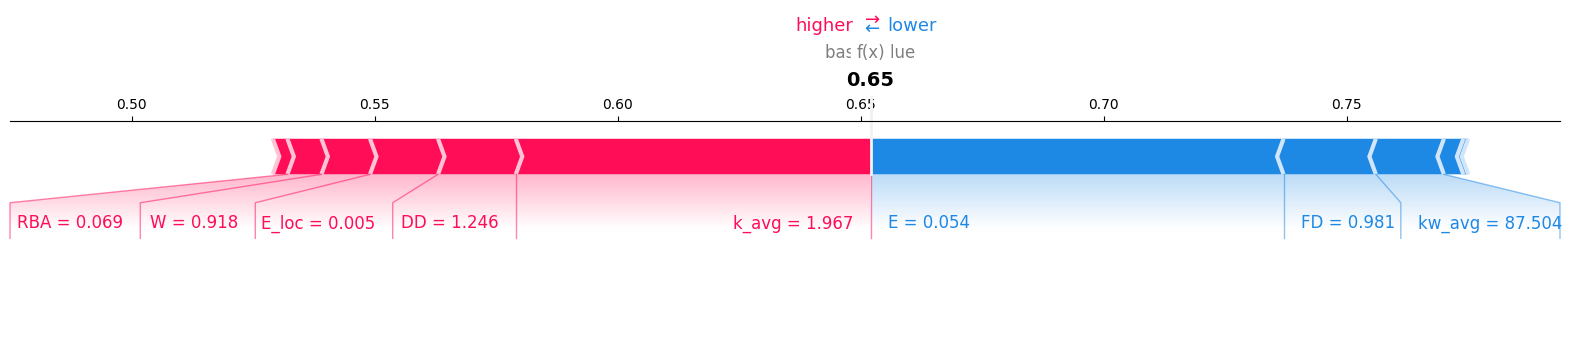

STEP: 1
[0.58745986]


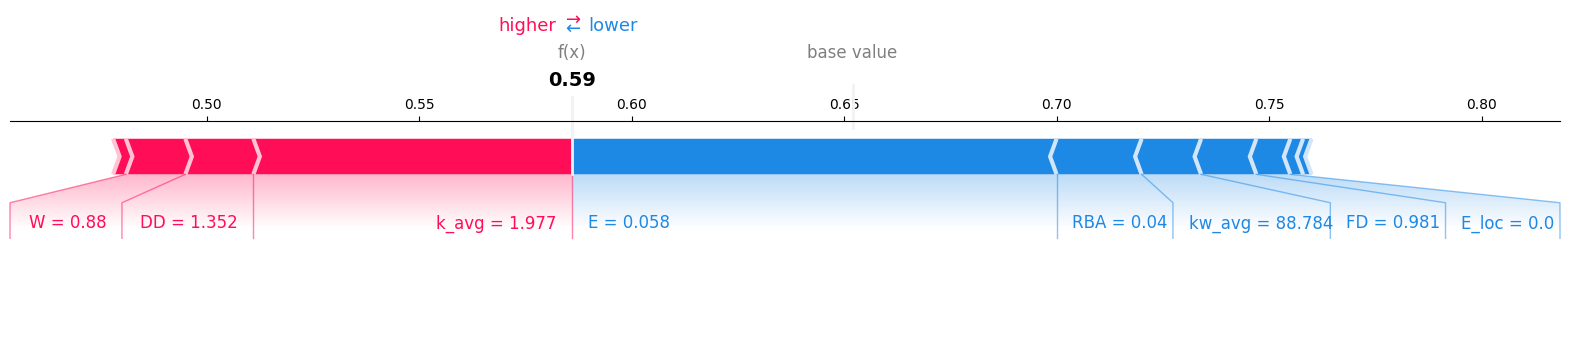

In [3]:
# IMG_PATH = '../Image-based load estimation/Data_Codes/All Images/Haunched/5.png'
# IMG_PATH = '../Image-based load estimation/Data_Codes/All Images/2meter/21.png'
# IMG_PATH = './paper_figure/1L-thinned-05-CS-full.png'
# IMG_PATH = './paper_figure/1L-skeleton-05-CS-full.png'

load_step = [0.25, 0.38, 0.5, 0.63, 0.76, 0.88, 1]
load_step_file = ['025', '038', '05', '063', '076', '088', '1']

# print(f"STEP: {step}")
# IMG_PATH = f'./paper_figure/1L-thin-1-CS-full.png'
# q, dq = multifractal_analysis(IMG_PATH, invert=False)
# dq = dq[::-1]
# alpha, f_alpha = calculate_singularity_spectrum(q, dq)
# mfa_param = analyze_multifractality(q, dq, alpha[::-1], f_alpha[::-1])

# # graph parameter
# ctg_param = crack_to_graph(IMG_PATH)
# graph_feature = feature_extraction(ctg_param[1], ctg_param[3])

# db_val = pd.DataFrame({'W'      : [mfa_param[0]],
#                         'DD'     : [mfa_param[1]],
#                         'LBA'    : [mfa_param[2]],
#                         'RBA'    : [mfa_param[3]],
#                         'FD'     : [mfa_param[4]],
#                         'ID'     : [mfa_param[5]],
#                         'CD'     : [mfa_param[6]],
#                         'C'      : [mfa_param[7]],
#                         'k_avg'  : [graph_feature[0]],
#                         'kw_avg' : [graph_feature[1]],
#                         'E'      : [graph_feature[2]],
#                         'E_loc'  : [graph_feature[3]],
#                         'a/d'    : [3.13],
#                         'd'      : [26.4],
#                         'fc'     : [44.8]})

# model = xgb.XGBRegressor()

# selected_param = ['W', 'DD', 'LBA', 'RBA', 'FD', 'ID', 'CD', 'C', 'k_avg', 'kw_avg', 'E', 'E_loc']
# model.load_model('./model_state/ML_LoadEstimation/XGB_ALL_PARAMETER.bin')
# load_estimate_1L = model.predict(db_val[selected_param])

# print(load_estimate_1L)

# multicrack parameter
for step in load_step_file:
    print(f"STEP: {step}")
    IMG_PATH = f'./paper_figure/1L-thin-{step}-CS-full.png'
    q, dq = multifractal_analysis(IMG_PATH, invert=False)
    dq = dq[::-1]
    alpha, f_alpha = calculate_singularity_spectrum(q, dq)
    mfa_param = analyze_multifractality(q, dq, alpha[::-1], f_alpha[::-1])

    # graph parameter
    ctg_param = crack_to_graph(IMG_PATH)
    graph_feature = feature_extraction(ctg_param[1], ctg_param[3])

    db_val = pd.DataFrame({'W'      : [mfa_param[0]],
                            'DD'     : [mfa_param[1]],
                            'LBA'    : [mfa_param[2]],
                            'RBA'    : [mfa_param[3]],
                            'FD'     : [mfa_param[4]],
                            'ID'     : [mfa_param[5]],
                            'CD'     : [mfa_param[6]],
                            'C'      : [mfa_param[7]],
                            'k_avg'  : [graph_feature[0]],
                            'kw_avg' : [graph_feature[1]],
                            'E'      : [graph_feature[2]],
                            'E_loc'  : [graph_feature[3]],
                            'a/d'    : [3.13],
                            'd'      : [26.4],
                            'fc'     : [44.8]})

    model = xgb.XGBRegressor()

    selected_param = ['W', 'DD', 'LBA', 'RBA', 'FD', 'ID', 'CD', 'C', 'k_avg', 'kw_avg', 'E', 'E_loc']
    model.load_model('./model_state/ML_LoadEstimation/XGB_ALL_PARAMETER.bin')
    load_estimate_1L = model.predict(db_val[selected_param])

    print(load_estimate_1L)

    explainer = shap.TreeExplainer(model)
    explanation = explainer(db_val[selected_param])

    shap_values = explanation.values
    # make sure the SHAP values add up to marginal predictions

    shap.plots.force(base_value=np.around(explainer.expected_value, decimals=3),
                    shap_values=np.around(shap_values[0], decimals=3),
                    features=np.around(db_val[selected_param].iloc[0], decimals=3),
                    matplotlib=True)